In [6]:
# ============================================================
# BLOQUE 1 : Importación de librerías
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración de visualización
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   seaborn    : {sns.__version__}")

Librerías importadas correctamente
   pandas     : 3.0.2
   numpy      : 2.4.4
   seaborn    : 0.13.2


In [8]:
# ============================================================
# BLOQUE 2: Carga del dataset
# ============================================================
# Carga de los conjuntos de entrenamiento y test
df_train = pd.read_csv('../data/aps_failure_training_set.csv', na_values='na', skiprows=20)
df_test  = pd.read_csv('../data/aps_failure_test_set.csv',  na_values='na', skiprows=20)

print("Dataset cargado correctamente")
print(f"\n Train : {df_train.shape[0]:,} filas x {df_train.shape[1]} columnas")
print(f" Test  : {df_test.shape[0]:,} filas x {df_test.shape[1]} columnas")


Dataset cargado correctamente

 Train : 60,000 filas x 171 columnas
 Test  : 16,000 filas x 171 columnas


In [9]:
# ============================================================
# BLOQUE 3: Exploración inicial del dataset
# ============================================================

print("=" * 60)
print("EXPLORACIÓN INICIAL")
print("=" * 60)

# Primeras filas
print("\nPrimeras 5 filas del dataset de entrenamiento:")
df_train.head()


EXPLORACIÓN INICIAL

Primeras 5 filas del dataset de entrenamiento:


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,...,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2130706438.0000,280.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,37250.0000,1432864.0000,3664156.0000,1007684.0000,25896.0000,0.0000,2551696.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4933296.0000,3655166.0000,...,0.0000,0.0000,202710.0000,37928.0000,14745580.0000,1876644.0000,0.0000,0.0000,0.0000,0.0000,2801180.0000,2445.8000,2712.0000,965866.0000,1706908.0000,1240520.0000,493384.0000,721044.0000,469792.0000,339156.0000,157956.0000,73224.0000,0.0000,0.0000,0.0000
1,neg,33058,NaN,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,18254.0000,653294.0000,1720800.0000,516724.0000,31642.0000,0.0000,1393352.0000,0.0000,68.0000,0.0000,0.0000,0.0000,2560898.0000,2127150.0000,...,0.0000,0.0000,103330.0000,16254.0000,4510080.0000,868538.0000,0.0000,0.0000,0.0000,0.0000,3477820.0000,2211.7600,2334.0000,664504.0000,824154.0000,421400.0000,178064.0000,293306.0000,245416.0000,133654.0000,81140.0000,97576.0000,1500.0000,0.0000,0.0000
2,neg,41040,NaN,228.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1648.0000,370592.0000,1883374.0000,292936.0000,12016.0000,0.0000,1234132.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2371990.0000,2173634.0000,...,0.0000,0.0000,65772.0000,10534.0000,300240.0000,48028.0000,0.0000,0.0000,0.0000,0.0000,1040120.0000,1018.6400,1020.0000,262032.0000,453378.0000,277378.0000,159812.0000,423992.0000,409564.0000,320746.0000,158022.0000,95128.0000,514.0000,0.0000,0.0000
3,neg,12,0.0000,70.0000,66.0000,0.0000,10.0000,0.0000,0.0000,0.0000,318.0000,2212.0000,3232.0000,1872.0000,0.0000,0.0000,0.0000,2668.0000,0.0000,0.0000,0.0000,642.0000,3894.0000,10184.0000,7554.0000,...,2014.0000,370.0000,48.0000,18.0000,15740.0000,1822.0000,20174.0000,44.0000,0.0000,0.0000,0.0000,1.0800,54.0000,5670.0000,1566.0000,240.0000,46.0000,58.0000,44.0000,10.0000,0.0000,0.0000,0.0000,4.0000,32.0000
4,neg,60874,NaN,1368.0000,458.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,43752.0000,1966618.0000,1800340.0000,131646.0000,4588.0000,0.0000,1974038.0000,0.0000,226.0000,0.0000,0.0000,0.0000,3230626.0000,2618878.0000,...,0.0000,0.0000,149474.0000,35154.0000,457040.0000,80482.0000,98334.0000,27588.0000,0.0000,0.0000,21173050.0000,1116.0600,1176.0000,404740.0000,904230.0000,622012.0000,229790.0000,405298.0000,347188.0000,286954.0000,311560.0000,433954.0000,1218.0000,0.0000,0.0000


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

Clase        Cantidad   Proporción
-----------------------------------
neg            59,000       98.33%
pos             1,000        1.67%

⚠️  Ratio de desbalance (neg/pos): 59.0:1


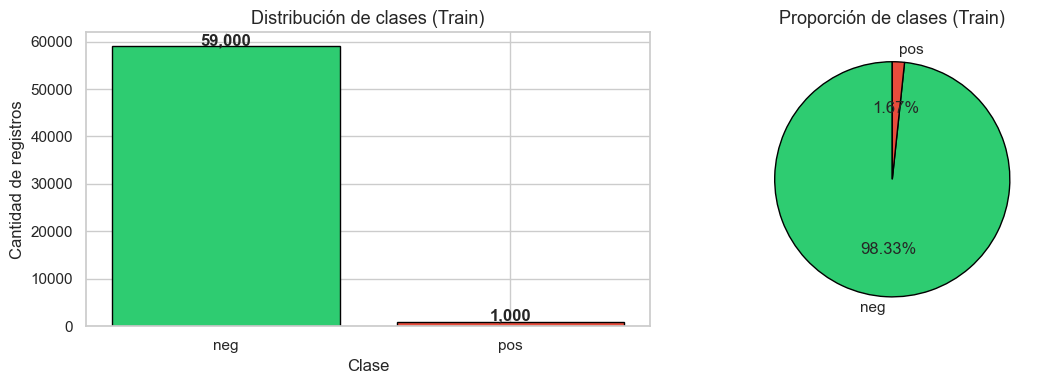


💾 Gráfico guardado en outputs/


In [10]:
# ============================================================
# BLOQUE 4: Análisis de la variable objetivo
# ============================================================

print("=" * 60)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 60)

# Conteo de clases
conteo = df_train['class'].value_counts()
proporcion = df_train['class'].value_counts(normalize=True) * 100

print(f"\n{'Clase':<10} {'Cantidad':>10} {'Proporción':>12}")
print("-" * 35)
for clase in conteo.index:
    print(f"{clase:<10} {conteo[clase]:>10,} {proporcion[clase]:>11.2f}%")

ratio = conteo['neg'] / conteo['pos']
print(f"\n⚠️  Ratio de desbalance (neg/pos): {ratio:.1f}:1")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
axes[0].bar(conteo.index, conteo.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribución de clases (Train)', fontsize=13)
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proporción de clases (Train)', fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/01_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Gráfico guardado en outputs/")

ANÁLISIS DE VALORES FALTANTES

Total de columnas con valores faltantes: 169 de 170 sensores
Columnas sin valores faltantes         : 1

Columnas con mas del 50% de faltantes  : 8
Columnas con 20%% - 50%% de faltantes  : 16
Columnas con menos del 20%% de faltantes: 145

Top 20 columnas con más valores faltantes:
        Faltantes  Porcentaje
br_000      49264     82.1067
bq_000      48722     81.2033
bp_000      47740     79.5667
bo_000      46333     77.2217
ab_000      46329     77.2150
cr_000      46329     77.2150
bn_000      44009     73.3483
bm_000      39549     65.9150
bl_000      27277     45.4617
bk_000      23034     38.3900
ad_000      14861     24.7683
cg_000      14861     24.7683
ch_000      14861     24.7683
cf_000      14861     24.7683
co_000      14861     24.7683
cx_000      13808     23.0133
cz_000      13808     23.0133
cy_000      13808     23.0133
dc_000      13808     23.0133
db_000      13808     23.0133


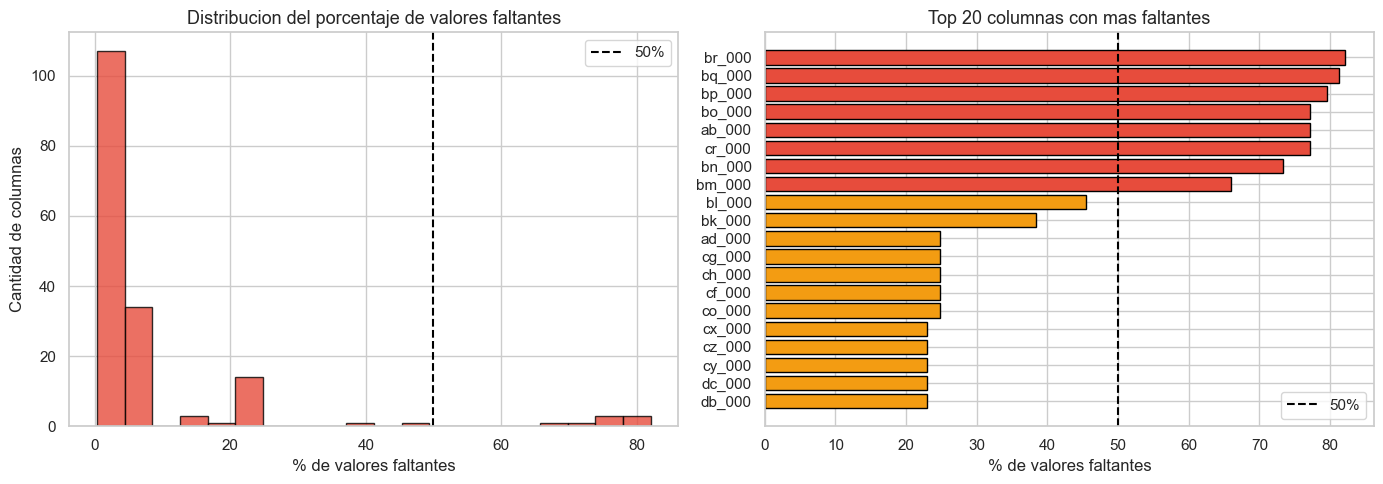

Grafico guardado en outputs/


In [11]:
# ============================================================
# BLOQUE 5: Análisis de valores faltantes
# ============================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Cálculo de missing values
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train)) * 100
missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Porcentaje': missing_pct
}).sort_values('Porcentaje', ascending=False)

# Solo columnas con al menos 1 faltante
missing_df = missing_df[missing_df['Faltantes'] > 0]

print(f"\nTotal de columnas con valores faltantes: {len(missing_df)} de {df_train.shape[1]-1} sensores")
print(f"Columnas sin valores faltantes         : {df_train.shape[1]-1 - len(missing_df)}")
print(f"\nColumnas con mas del 50% de faltantes  : {(missing_df['Porcentaje'] > 50).sum()}")
print(f"Columnas con 20%% - 50%% de faltantes  : {((missing_df['Porcentaje'] >= 20) & (missing_df['Porcentaje'] <= 50)).sum()}")
print(f"Columnas con menos del 20%% de faltantes: {(missing_df['Porcentaje'] < 20).sum()}")

# Top 20 columnas con más faltantes
print(f"\nTop 20 columnas con más valores faltantes:")
print(missing_df.head(20).to_string())

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de porcentaje de faltantes
axes[0].hist(missing_df['Porcentaje'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].axvline(x=50, color='black', linestyle='--', linewidth=1.5, label='50%')
axes[0].set_title('Distribucion del porcentaje de valores faltantes', fontsize=13)
axes[0].set_xlabel('% de valores faltantes')
axes[0].set_ylabel('Cantidad de columnas')
axes[0].legend()

# Barplot top 20
top20 = missing_df.head(20)
colors = ['#e74c3c' if p > 50 else '#f39c12' if p >= 20 else '#2ecc71'
          for p in top20['Porcentaje']]
axes[1].barh(top20.index, top20['Porcentaje'], color=colors, edgecolor='black')
axes[1].axvline(x=50, color='black', linestyle='--', linewidth=1.5, label='50%')
axes[1].set_title('Top 20 columnas con mas faltantes', fontsize=13)
axes[1].set_xlabel('% de valores faltantes')
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/02_valores_faltantes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado en outputs/")

In [12]:
# ============================================================
# BLOQUE 6: Preprocesamiento
# ============================================================

from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("PREPROCESAMIENTO")
print("=" * 60)

# --- Paso 1: Separar variable objetivo ---
X_train_raw = df_train.drop(columns=['class'])
y_train      = (df_train['class'] == 'pos').astype(int)

X_test_raw   = df_test.drop(columns=['class'])
y_test        = (df_test['class'] == 'pos').astype(int)

print(f"\nVariable objetivo codificada: neg=0, pos=1")
print(f"Distribucion y_train -> 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}")
print(f"Distribucion y_test  -> 0: {(y_test==0).sum():,}   |  1: {(y_test==1).sum():,}")

# --- Paso 2: Imputacion por mediana ---
print("\nAplicando imputacion por mediana...")

# Calcular medianas SOLO sobre train para evitar data leakage
medianas = X_train_raw.median()

X_train_imp = X_train_raw.fillna(medianas)
X_test_imp  = X_test_raw.fillna(medianas)

missing_post = X_train_imp.isnull().sum().sum()
print(f"Valores faltantes en train tras imputacion: {missing_post}")

# --- Paso 3: Normalizacion con StandardScaler ---
print("Aplicando normalizacion StandardScaler...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Convertir a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_imp.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test_imp.columns)

print(f"Shape final train : {X_train_scaled.shape}")
print(f"Shape final test  : {X_test_scaled.shape}")

# --- Verificacion: estadisticas post-normalizacion ---
stats = X_train_scaled.describe().loc[['mean', 'std']].T
print(f"\nVerificacion normalizacion (primeras 5 columnas):")
print(stats.head().to_string())

print("\nPreprocesamiento completado.")

PREPROCESAMIENTO

Variable objetivo codificada: neg=0, pos=1
Distribucion y_train -> 0: 59,000  |  1: 1,000
Distribucion y_test  -> 0: 15,625   |  1: 375

Aplicando imputacion por mediana...
Valores faltantes en train tras imputacion: 0
Aplicando normalizacion StandardScaler...
Shape final train : (60000, 170)
Shape final test  : (16000, 170)

Verificacion normalizacion (primeras 5 columnas):
          mean    std
aa_000  0.0000 1.0000
ab_000  0.0000 1.0000
ac_000  0.0000 1.0000
ad_000 -0.0000 1.0000
ae_000  0.0000 1.0000

Preprocesamiento completado.


In [13]:
# ============================================================
# BLOQUE 7: Guardado de datos procesados
# ============================================================

import os

# Crear carpeta si no existe
os.makedirs('../data/processed', exist_ok=True)

# Guardar conjuntos procesados
X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv',   index=False)
y_train.to_csv('../data/processed/y_train.csv',        index=False)
y_test.to_csv('../data/processed/y_test.csv',          index=False)

print("Datos procesados guardados en data/processed/")
print(f"   X_train.csv : {X_train_scaled.shape}")
print(f"   X_test.csv  : {X_test_scaled.shape}")
print(f"   y_train.csv : {y_train.shape}")
print(f"   y_test.csv  : {y_test.shape}")

Datos procesados guardados en data/processed/
   X_train.csv : (60000, 170)
   X_test.csv  : (16000, 170)
   y_train.csv : (60000,)
   y_test.csv  : (16000,)
